# QR-FTLE reference generation from the memcapacitive oscillator

This notebook generates the **analytical reference trajectories** used throughout the manuscript by integrating the full memcapacitive oscillator and computing the sliding **QR-Benettin finite-time Lyapunov exponents**.

Its role in the manuscript is foundational: it does **not** produce a data-driven proxy, but rather the equation-based benchmark $(\lambda_{\mathrm{QR}})$ against which the ML-FTLE and Poincaré-FTLE estimators are evaluated in the subsequent figure notebooks.

For each parameter set $(\mathcal{D}_k)$, the notebook:

1. integrates the governing nonlinear ODE after transient removal,
2. saves the scalar trajectory used by the proxy pipelines,
3. computes the local QR-Benettin Lyapunov spectrum over sliding windows, and
4. stores both the raw and smoothed leading exponent for downstream comparison.

The main exported files are:

- `ode_trajectory.csv` — equation-generated scalar observable,
- `qr_ftle.csv` — analytical sliding FTLE reference containing $(\lambda_1), (\lambda_2), (\lambda_3)$.


In [1]:
import time, json, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from pathlib import Path
from typing import Dict, List, Tuple
from matplotlib.colors import TwoSlopeNorm
print("Imports OK")


Imports OK


### `c01_imports` — Scientific stack and plotting backend

Loads the numerical, tabular, and plotting libraries required for reference trajectory generation and QR-based FTLE analysis.

This cell provides the computational environment for the manuscript's analytical benchmark construction, including ODE integration, interpolation support, dataframe export, and figure generation.


In [2]:
# ── Auto-discover every parameters/data_N.py and run ─────────────────────────
from parameters import discover_all_params
PARAM_SETS = discover_all_params()
print(f"\n{len(PARAM_SETS)} dataset(s) will be processed.")


Discovered 3 parameter file(s) in d:\NLD_PROJECT\ML_FTLE\publication code - Copy\parameters:
  ✓  data_1.py  →  OUT_DIR=d:\NLD_PROJECT\ML_FTLE\publication code - Copy\data\data_1
  ✓  data_2.py  →  OUT_DIR=d:\NLD_PROJECT\ML_FTLE\publication code - Copy\data\data_2
  ✓  data_3.py  →  OUT_DIR=d:\NLD_PROJECT\ML_FTLE\publication code - Copy\data\data_3

3 dataset(s) will be processed.


### `c02_discover_parameters` — Automatic discovery of manuscript datasets

Discovers all parameter modules in `parameters/data_N.py` and prepares them for batch execution.

This design keeps the QR-FTLE benchmark generation synchronized with the manuscript's dataset structure, so the same notebook can reproduce the analytical reference for all scenarios $(\mathcal{D}_1, \mathcal{D}_2, \mathcal{D}_3)$ without manual code edits.


In [ ]:
def system_ode(t, u, a, b, c, dd, e):
    u1, u2, u3 = u
    return [-u2, a*(-b*u2+(u3**2-c)*u1), u1**2-dd*u3-e]

def jacobian(u, a, b, c, dd, e):
    u1, u2, u3 = u
    return np.array([
        [0.0,          -1.0,  0.0      ],
        [a*(u3**2-c),  -a*b,  2*a*u1*u3],
        [2*u1,          0.0,  -dd      ],
    ])

def _integrate_base(u_start, t_span, t_eval):
    # PARAMS is read from globals at call time — safe after run_ode_dataset sets it
    sol = solve_ivp(system_ode, t_span, u_start, args=PARAMS,
                    method="RK45", t_eval=t_eval, rtol=1e-9, atol=1e-12)
    if not sol.success: raise RuntimeError(sol.message)
    return sol.y.T

def _integrate_variational(u_start, n_steps, dt):
    n = len(u_start)
    def rhs(t, s):
        u = s[:n]; Q = s[n:].reshape(n, n)
        return np.concatenate([system_ode(t, u, *PARAMS),
                                (jacobian(u, *PARAMS) @ Q).ravel()])
    s0  = np.concatenate([u_start, np.eye(n).ravel()])
    sol = solve_ivp(rhs, [0, n_steps*dt], s0, method="RK45",
                    rtol=1e-9, atol=1e-12, t_eval=[n_steps*dt])
    return sol.y[:n, -1], sol.y[n:, -1].reshape(n, n)

def lyapunov_qr(u_start, n_steps, renorm=None, dt=None):
    # ↑ None defaults — resolved from globals at call time, not definition time
    if renorm is None: renorm = RENORM_INTERVAL   # set by run_ode_dataset()
    if dt     is None: dt     = DT                 # set by run_ode_dataset()
    n, u = len(u_start), u_start.copy()
    Q, log_R = np.eye(n), np.zeros(n)
    for _ in range(n_steps // renorm):
        u, Qn = _integrate_variational(u, renorm, dt)
        W = Qn @ Q; Q, R = np.linalg.qr(W)
        s = np.sign(np.diag(R)); Q *= s; R *= s[:, None]
        log_R += np.log(np.abs(np.diag(R)))
    return log_R / (n_steps // renorm * renorm * dt)

print("ODE helpers defined  (lyapunov_qr uses None-default args — safe before params load).")


ODE helpers defined  (lyapunov_qr uses None-default args — safe before params load).


### `c03_ode_helpers` — Governing dynamics and QR-Benettin core functions

Defines the memcapacitive oscillator, its Jacobian, the base ODE integrator, the variational integrator, and the QR-Benettin Lyapunov routine.

These functions form the analytical backbone of the manuscript because they generate the equation-driven finite-time Lyapunov spectrum directly from the governing system.


In [4]:
# ── Per-dataset runner ────────────────────────────────────────────────────────
def run_ode_dataset(data_id, P):
    global PARAMS, DT, TTR, N_TOTAL, T_WINDOW_STEPS, T_STEP, T_WINDOW
    global RENORM_INTERVAL, LLE_THRESH, SMOOTH_WINDOW, ODE_CSV, QR_CSV, OUT_DIR
    PARAMS          = P.PARAMS
    DT              = P.DT
    TTR             = P.TTR
    N_TOTAL         = P.N_TOTAL
    T_WINDOW_STEPS  = P.T_WINDOW_STEPS
    T_STEP          = P.T_STEP
    T_WINDOW        = P.T_WINDOW
    RENORM_INTERVAL = P.RENORM_INTERVAL
    LLE_THRESH      = P.LLE_THRESH
    SMOOTH_WINDOW   = P.SMOOTH_WINDOW
    ODE_CSV         = P.ODE_CSV
    QR_CSV          = P.QR_CSV
    OUT_DIR         = P.OUT_DIR
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    ODE_CSV.parent.mkdir(parents=True, exist_ok=True)  # ← ADD THIS if ODE_CSV is in a subdir
    
    U0           = np.array(P.INITIAL_CONDITIONS)
    T_TOTAL_TIME = N_TOTAL * DT
    N_WINDOWS    = (N_TOTAL - T_WINDOW_STEPS) // T_STEP + 1
    print(f"  T_WINDOW_STEPS={T_WINDOW_STEPS}  T_STEP={T_STEP}  "
          f"DT={DT}  N_WINDOWS={N_WINDOWS}  RENORM_INTERVAL={RENORM_INTERVAL}")
    # ── Step 1: burn transient ────────────────────────────────────────────────
    t_tr  = np.arange(0, TTR*DT + DT/2, DT)
    u_set = _integrate_base(U0, [0, TTR*DT], t_tr)[-1].copy()
    print(f"  u_settled = {np.round(u_set, 5)}")
    # ── Step 2: analysis trajectory ──────────────────────────────────────────
    T_ts   = np.arange(0, T_TOTAL_TIME + DT/2, DT)
    Traj   = _integrate_base(u_set, [0, T_TOTAL_TIME], T_ts)
    signal = Traj[:, 0]
    pd.DataFrame({"time": T_ts, "x": signal}).to_csv(ODE_CSV, index=False)
    print(f"  Saved → {ODE_CSV}  shape={Traj.shape}")
    # ── Step 3: sliding QR-FTLE ──────────────────────────────────────────────
    times_qr = np.zeros(N_WINDOWS)
    lam1 = np.zeros(N_WINDOWS)
    lam2 = np.zeros(N_WINDOWS)
    lam3 = np.zeros(N_WINDOWS)
    t0_run = time.time()
    for i in range(N_WINDOWS):
        i0  = i * T_STEP
        tc  = T_ts[i0] + T_WINDOW / 2
        lam = lyapunov_qr(Traj[i0].copy(), T_WINDOW_STEPS)
        times_qr[i] = tc
        lam1[i], lam2[i], lam3[i] = lam[0], lam[1], lam[2]
        if (i + 1) % 20 == 0 or i == 0:
            print(f"    [{i+1:3d}/{N_WINDOWS}] t={tc:8.1f}  "
                  f"λ₁={lam[0]:+.5f}  ({time.time()-t0_run:.0f}s)")
    df_qr = pd.DataFrame({"time": times_qr,
                           "lam1_qr": lam1, "lam2_qr": lam2, "lam3_qr": lam3})
    df_qr["lam1_qr_smooth"] = (df_qr["lam1_qr"]
                                .rolling(SMOOTH_WINDOW, center=True, min_periods=5)
                                .median())
    df_qr.to_csv(QR_CSV, index=False)
    print(f"  Saved → {QR_CSV}")
    
    print(f" ✓ {data_id} core QR computation complete")
print("run_ode_dataset defined.")


run_ode_dataset defined.


### `c04_run_ode_dataset` — Per-dataset analytical reference generator

Builds the full analytical pipeline for a single dataset.

For each parameter set, the function removes the transient, integrates the physical trajectory, computes the sliding QR-Benettin Lyapunov exponents, stores the reference series in `qr_ftle.csv`, and saves the scalar signal in `ode_trajectory.csv` for use by the downstream ML-FTLE and Poincaré-FTLE notebooks.


In [5]:
# ── MASTER LOOP — runs every discovered dataset ───────────────────────────────
for data_id, P in PARAM_SETS.items():
    print(f"\n{'='*62}\n  ODE Solver: {data_id}\n{'='*62}")
    run_ode_dataset(data_id, P)

print("\n✓  ode_solver complete for all datasets.")



  ODE Solver: data_1
  T_WINDOW_STEPS=500  T_STEP=30  DT=1  N_WINDOWS=184  RENORM_INTERVAL=10
  u_settled = [-0.37893  0.08344  0.36134]
  Saved → d:\NLD_PROJECT\ML_FTLE\publication code - Copy\data\data_1\csv_mkg\ode_trajectory.csv  shape=(6001, 3)
    [  1/184] t=   250.0  λ₁=+0.02821  (1s)
    [ 20/184] t=   820.0  λ₁=+0.02750  (15s)
    [ 40/184] t=  1420.0  λ₁=+0.03683  (31s)
    [ 60/184] t=  2020.0  λ₁=+0.00477  (46s)
    [ 80/184] t=  2620.0  λ₁=+0.00106  (62s)
    [100/184] t=  3220.0  λ₁=-0.00267  (76s)
    [120/184] t=  3820.0  λ₁=-0.00162  (90s)
    [140/184] t=  4420.0  λ₁=-0.00157  (103s)
    [160/184] t=  5020.0  λ₁=-0.00155  (116s)
    [180/184] t=  5620.0  λ₁=-0.00155  (129s)
  Saved → d:\NLD_PROJECT\ML_FTLE\publication code - Copy\data\data_1\qr_ftle.csv
 ✓ data_1 core QR computation complete

  ODE Solver: data_2
  T_WINDOW_STEPS=400  T_STEP=50  DT=1  N_WINDOWS=113  RENORM_INTERVAL=10
  u_settled = [-0.07069 -0.03683  1.13437]
  Saved → d:\NLD_PROJECT\ML_FTLE\public

### `c05_master_loop` — Batch execution across all manuscript datasets

Runs the analytical QR-FTLE generation pipeline across every discovered dataset.

This cell is the batch entry point used to reproduce the benchmark reference files for the full manuscript, ensuring that all subsequent figure notebooks are driven by consistently generated equation-based FTLE targets.



Plotting saved QR outputs: data_1


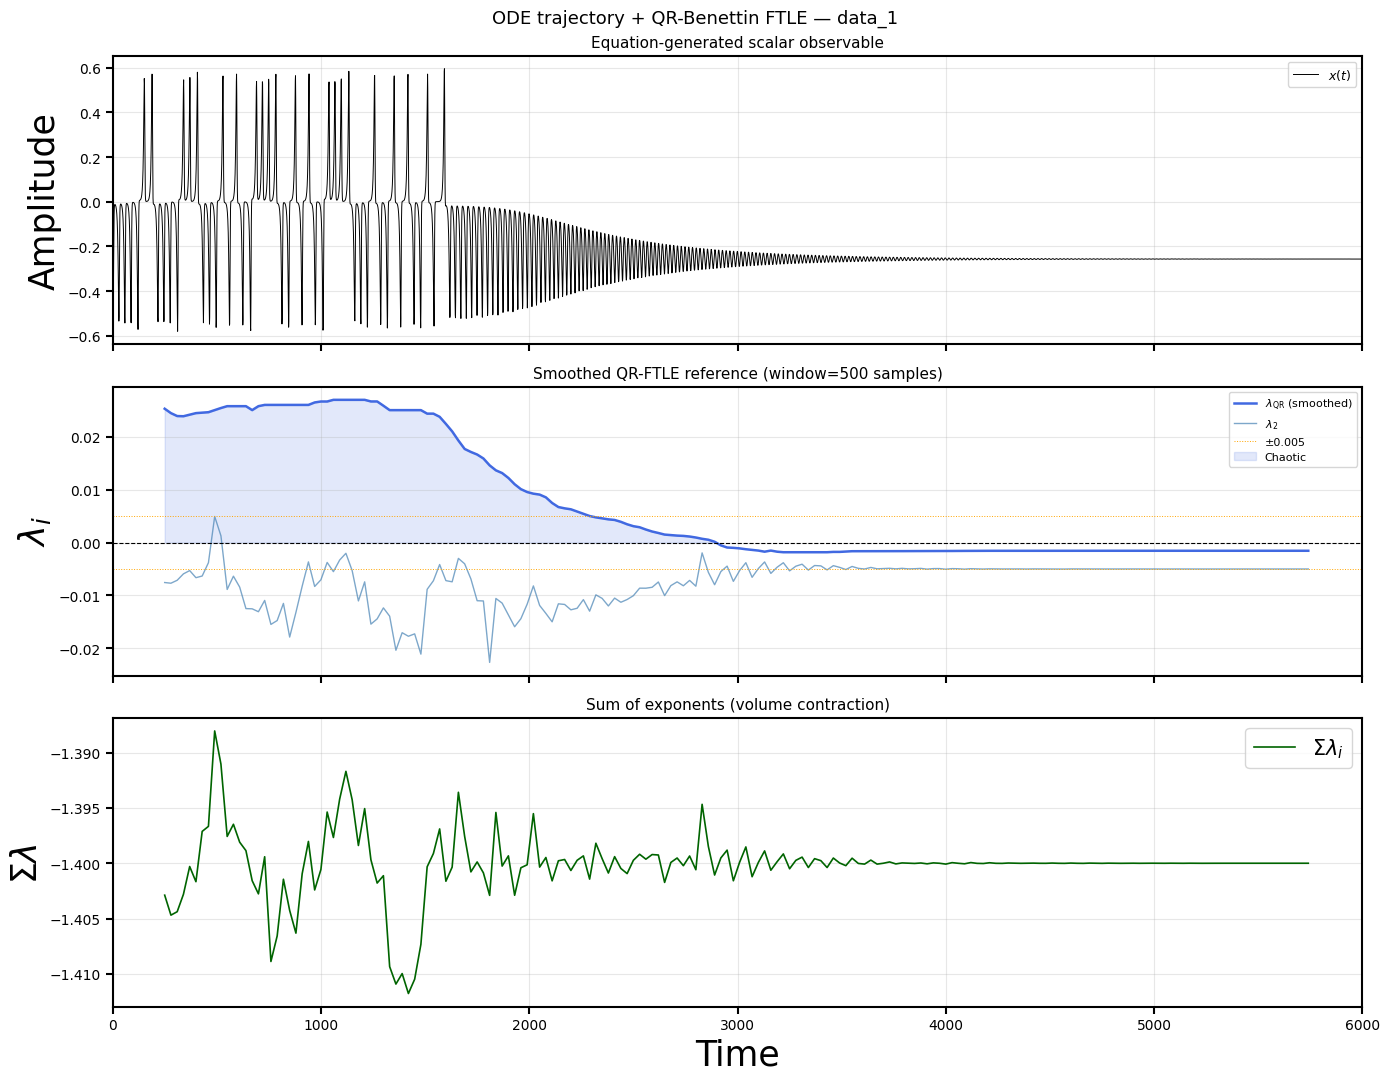


Plotting saved QR outputs: data_2


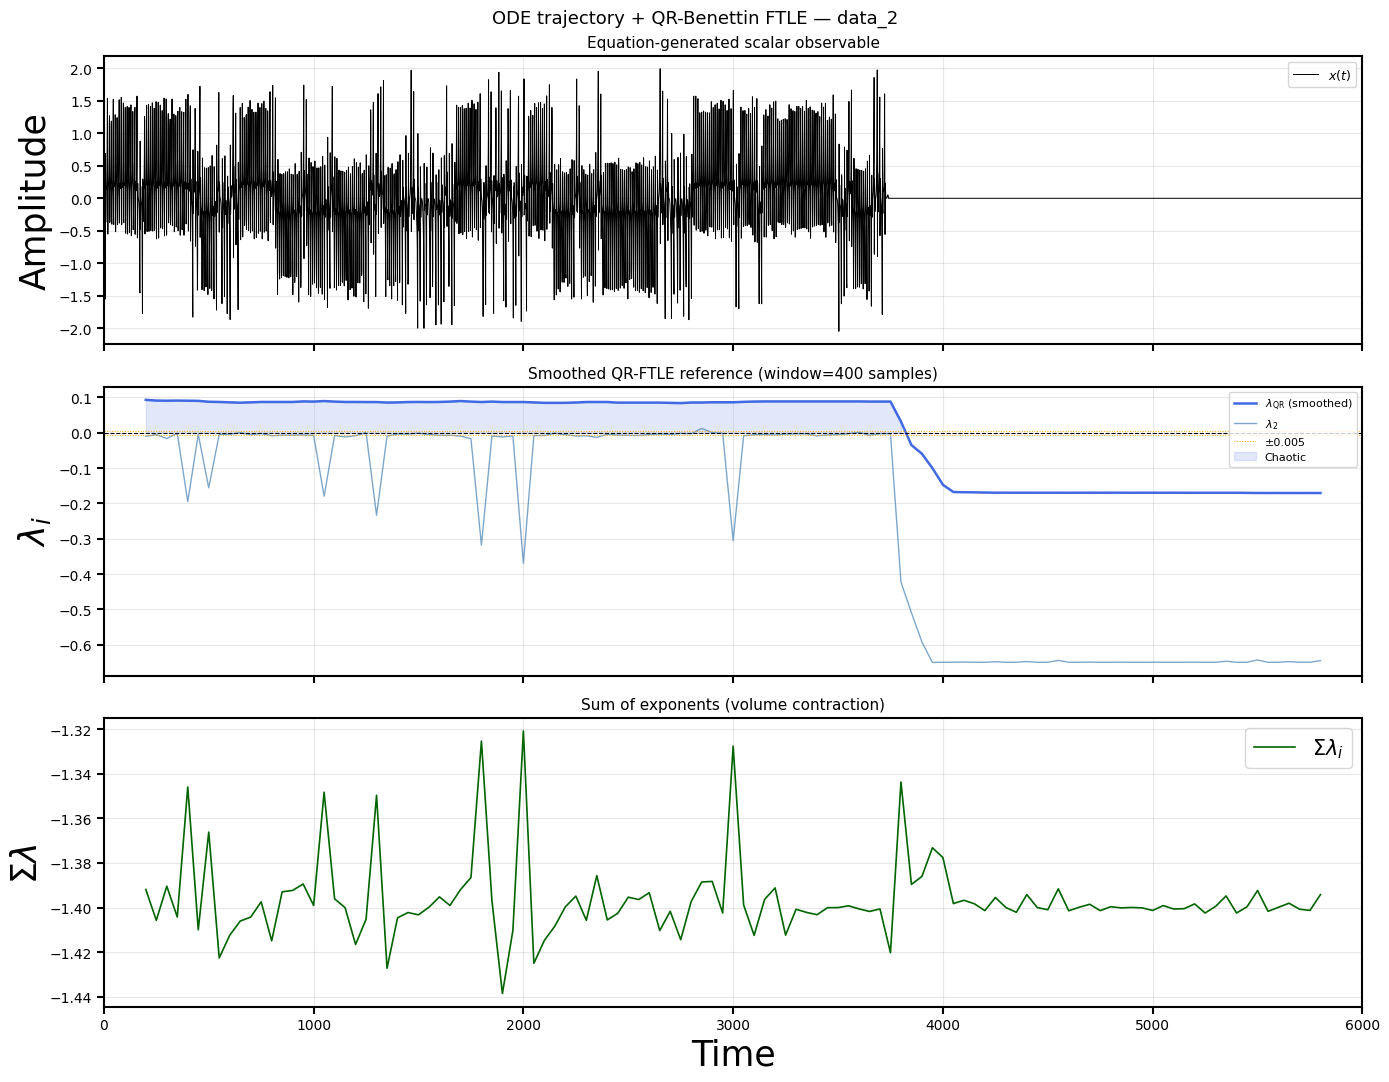


Plotting saved QR outputs: data_3


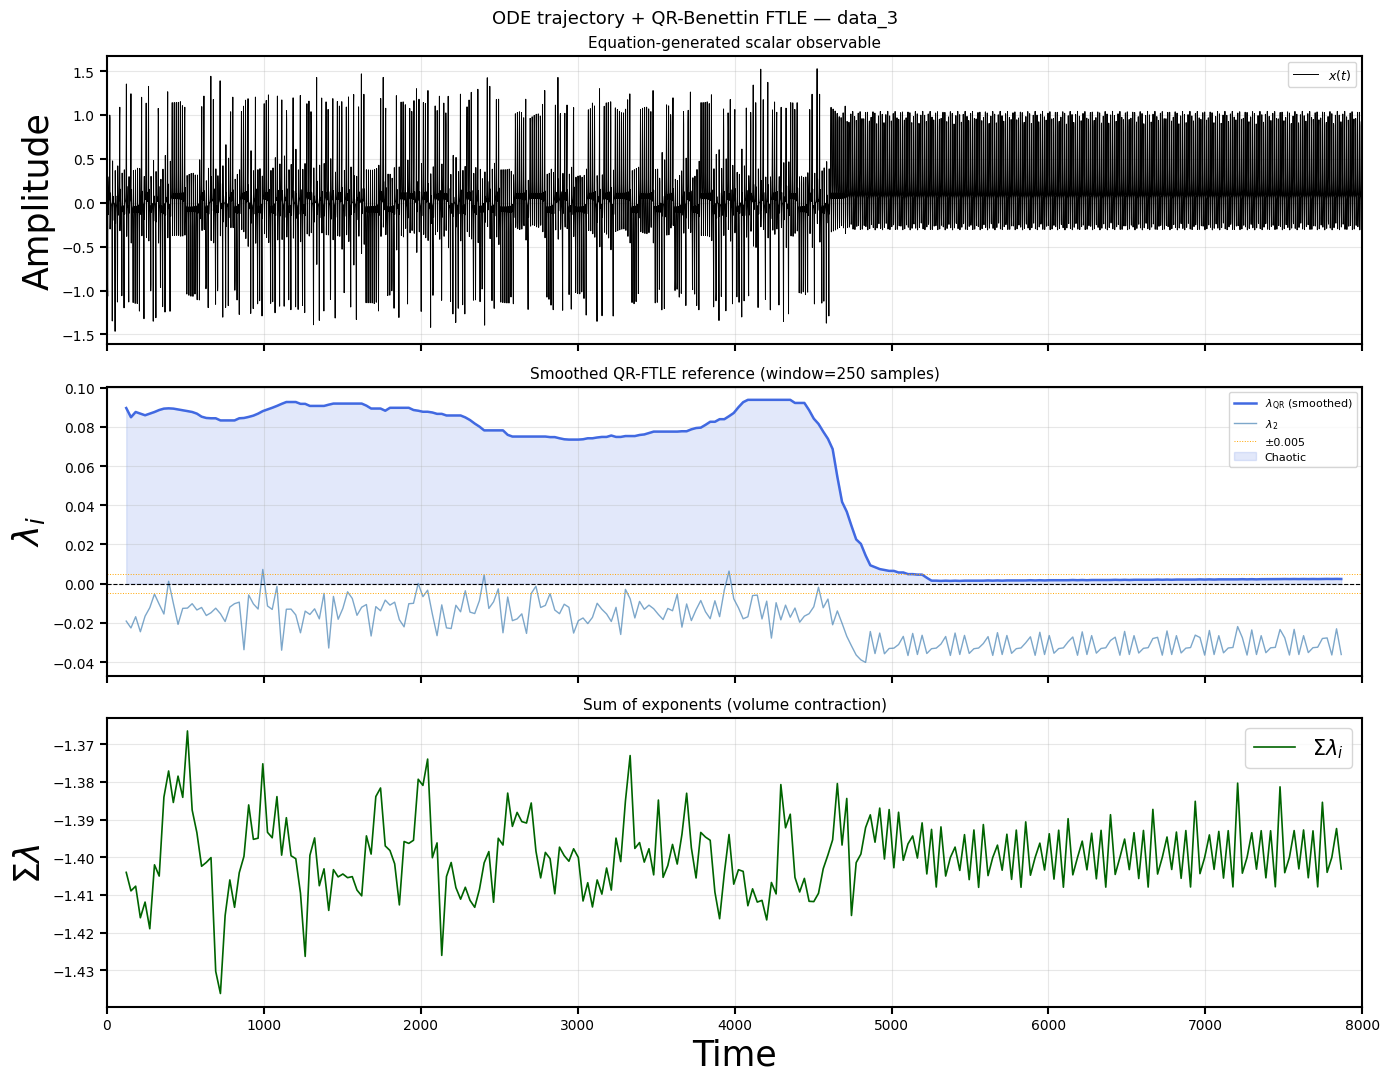

In [8]:
# ── Independent plotting from saved CSV outputs ─────────────────────────────
def plot_qr_from_saved(data_id, P):
    ode_df = pd.read_csv(P.ODE_CSV)
    qr_df = pd.read_csv(P.QR_CSV)

    T_ts = ode_df["time"].to_numpy()
    x = ode_df["x"].to_numpy()
    times_qr = qr_df["time"].to_numpy()
    lam1_s = qr_df["lam1_qr_smooth"].to_numpy()
    lam2 = qr_df["lam2_qr"].to_numpy()
    lam3 = qr_df["lam3_qr"].to_numpy()

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
    fig.suptitle(f"ODE trajectory + QR-Benettin FTLE — {data_id}", fontsize=13)
    XLIMS = (T_ts[0], T_ts[-1])

    def _style(ax, title, ylabel):
        ax.set_title(title, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=25)
        ax.set_xlim(XLIMS)
        ax.grid(True, alpha=0.3)
        for sp in ax.spines.values():
            sp.set_linewidth(1.5)
        ax.tick_params(width=1.5, length=5)

    axes[0].plot(T_ts, x, lw=0.7, color="black", label=r"$x(t)$")
    axes[0].legend(fontsize=9, loc="upper right")
    _style(axes[0], "Equation-generated scalar observable", "Amplitude")

    axes[1].plot(times_qr, lam1_s, lw=1.8, color="royalblue", label=r"$\lambda_{\mathrm{QR}}$ (smoothed)")
    axes[1].plot(times_qr, lam2, lw=1.0, color="steelblue", alpha=0.7, label=r"$\lambda_2$")
    axes[1].axhline(0, lw=0.8, ls="--", color="black")
    axes[1].axhline(P.LLE_THRESH, lw=0.7, ls=":", color="orange", label=f"±{P.LLE_THRESH}")
    axes[1].axhline(-P.LLE_THRESH, lw=0.7, ls=":", color="orange")
    axes[1].fill_between(times_qr, 0, lam1_s, where=(lam1_s > 0), color="royalblue", alpha=0.15, label="Chaotic")
    axes[1].legend(fontsize=8, loc="upper right")
    _style(axes[1], f"Smoothed QR-FTLE reference (window={P.T_WINDOW_STEPS} samples)", r"$\lambda_i$")

    axes[2].plot(times_qr, lam1_s + lam2 + lam3, lw=1.2, color="darkgreen", label=r"$\Sigma\lambda_i$")
    axes[2].legend(fontsize=15)
    axes[2].set_xlabel("Time", fontsize=25)
    _style(axes[2], "Sum of exponents (volume contraction)", r"$\Sigma\lambda$")

    plt.tight_layout()
    plt.savefig(P.OUT_DIR / "qr_ftle_summary.png", dpi=300)
    plt.show()

for data_id, P in PARAM_SETS.items():
    print(f"\nPlotting saved QR outputs: {data_id}")
    plot_qr_from_saved(data_id, P)

